In [3]:
import yfinance as yf
import pandas as pd
import datetime as dt

import hist_volatility
from riskfree_and_spot import *
from hist_volatility import *
from blackscholes import *
from binomial import *

In [7]:
data = pd.read_csv("../data/option_data_calc.csv")

In [12]:
iv_fig_data = data[
    (data["bid"] > 0) &
    (data["ask"] > 0) &
    (data["openInterest"] > 0) &
    (data["inTheMoney"] == True)
    # (data["strike"] > spot_for_iv * 0.8) &
    # (data["strike"] < spot_for_iv * 1.2)
]

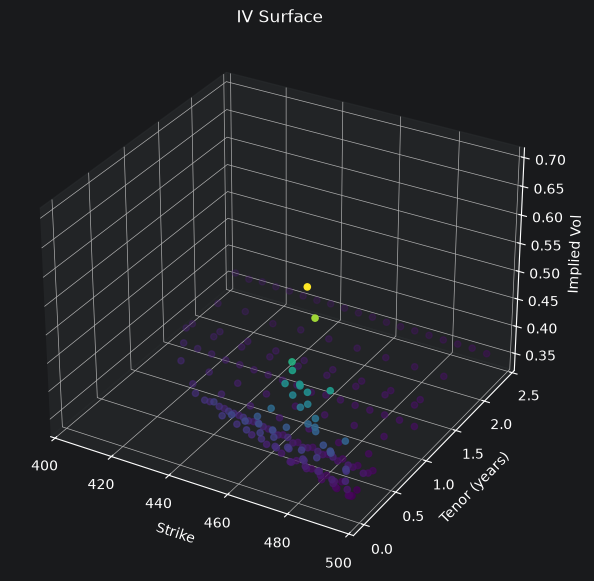

In [13]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(iv_fig_data["strike"], iv_fig_data["tenor"], iv_fig_data["imp_vol"], c=iv_fig_data["imp_vol"], cmap="viridis")
ax.set_xlabel("Strike")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
ax.set_title(f"IV Surface")
plt.show()

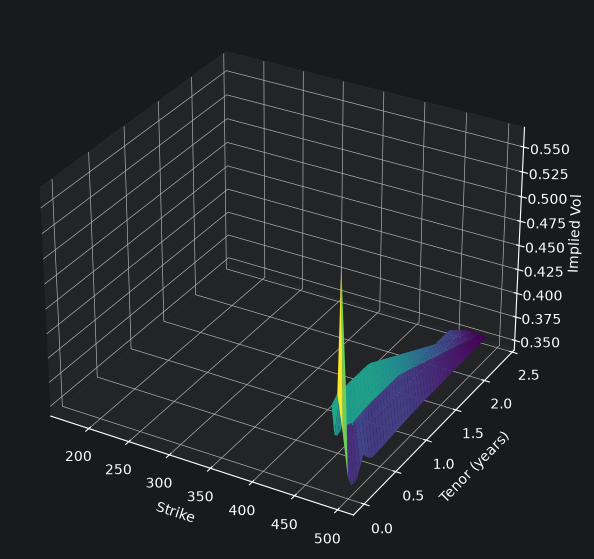

In [14]:
from scipy.interpolate import griddata

strikes = np.linspace(iv_fig_data["strike"].min(), iv_fig_data["strike"].max(), 50)
tenors = np.linspace(iv_fig_data["tenor"].min(), iv_fig_data["tenor"].max(), 50)
grid_x, grid_y = np.meshgrid(strikes, tenors)

grid_z = griddata(
    (iv_fig_data["strike"], iv_fig_data["tenor"]),
    iv_fig_data["imp_vol"],
    (grid_x, grid_y),
    method="linear"
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_x, grid_y, grid_z, cmap="viridis")
ax.set_xlabel("Strike")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
plt.show()